<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/test_root_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install uproot
import uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 36.8 MB/s eta 0:00:00


using test root

Viking.mac:
/control/verbose 0

/control/execute /users/mw2304/geant4_apps/QEPET/build/quiet.mac

/process/em/QuantumEntanglement true

/run/numberOfThreads 1

'# To enable 3-gamma annihilations
'#/process/em/setPositronAtRestModel OrePowellPolar'

'#/material/g4/ortoPositroniumFraction G4_AIR 1.0

'#/material/g4/ortoPositroniumFraction G4_WATER 1.0

'#/material/g4/ortoPositroniumFraction G4_BONE_COMPACT_ICRU 1.0

'# Activate/deactivate non-collinearity
/QEPET/det/nonCollin false

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomTissues.mac

/run/initialize

/control/execute /users/mw2304/geant4_apps/QEPET/build/randomSources.mac

/run/beamOn 100000


In [14]:
import matplotlib.pyplot as plt

rootfile = uproot.open('test.root')
print(rootfile.keys())

['NCS;1', 'PhantomSCS;1', 'ScannerSCS;1', 'PhantomSCS_ScannerSCS;1', 'PhantomDCS;1', 'ScannerDCS;1', 'PhantomSCS_ScannerDCS;1', 'PhantomDCS_ScannerSCS;1', 'PhantomDCS_ScannerDCS;1', 'MCS;1', 'Excluded;1']


In [15]:
tree = rootfile["NCS"]

print(tree.num_entries)

4218.0


In [16]:
for key in rootfile.keys():
    obj = rootfile[key]
    if hasattr(obj, "num_entries"):
        print(key, obj.num_entries)

NCS;1 4218.0
PhantomSCS;1 1844.0
ScannerSCS;1 9299.0
PhantomSCS_ScannerSCS;1 3015.0
PhantomDCS;1 157.0
ScannerDCS;1 5288.0
PhantomSCS_ScannerDCS;1 1102.0
PhantomDCS_ScannerSCS;1 166.0
PhantomDCS_ScannerDCS;1 40.0
MCS;1 0.0
Excluded;1 0.0


In [17]:
tree = rootfile['NCS']
print(tree.keys())

['AnnihilX', 'AnnihilY', 'AnnihilZ', 'Gamma1_ScatterX', 'Gamma1_ScatterY', 'Gamma1_ScatterZ', 'Gamma1_Theta', 'Gamma1_HitE1', 'Gamma1_HitX1', 'Gamma1_HitY1', 'Gamma1_HitZ1', 'Gamma1_HitE2', 'Gamma1_HitX2', 'Gamma1_HitY2', 'Gamma1_HitZ2', 'Gamma2_ScatterX', 'Gamma2_ScatterY', 'Gamma2_ScatterZ', 'Gamma2_Theta', 'Gamma2_HitE1', 'Gamma2_HitX1', 'Gamma2_HitY1', 'Gamma2_HitZ1', 'Gamma2_HitE2', 'Gamma2_HitX2', 'Gamma2_HitY2', 'Gamma2_HitZ2', 'DeltaPhi']


In [18]:
x = tree["AnnihilX"].array(library="np")

print(type(x))
print(len(x))
print(x[:10])

<class 'numpy.ndarray'>
4218
[-1.0355828   2.528145    4.5318255   1.666726    3.7932696   2.8061187
  0.29709366  1.5279022   3.3034244   5.127826  ]


anhilation X posiiton histogram

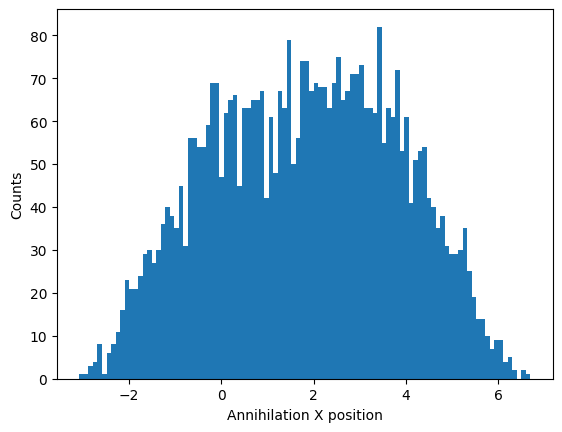

In [19]:
plt.hist(x, bins=100)
plt.xlabel("Annihilation X position")
plt.ylabel("Counts")
plt.show()

Anhilation distrbution

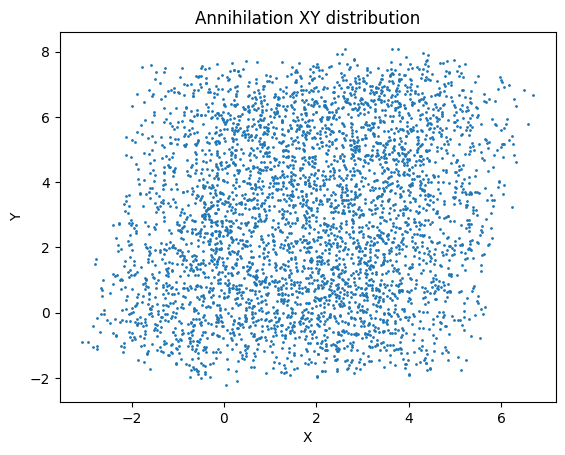

In [20]:
x = tree["AnnihilX"].array()
y = tree["AnnihilY"].array()

plt.scatter(x, y, s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Annihilation XY distribution")
plt.show()

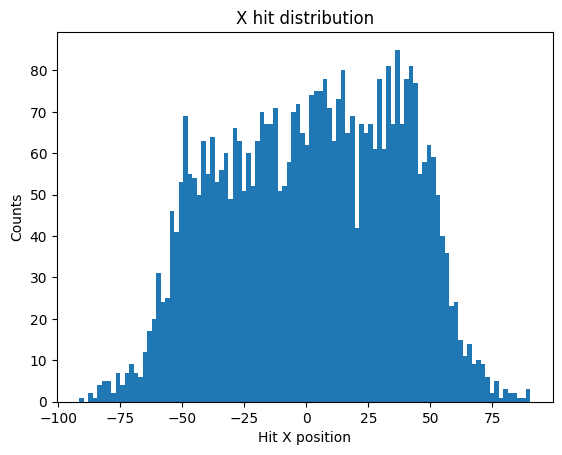

In [21]:
x = tree["Gamma1_HitX1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit X position")
plt.ylabel("Counts")
plt.title("X hit distribution")
plt.show()

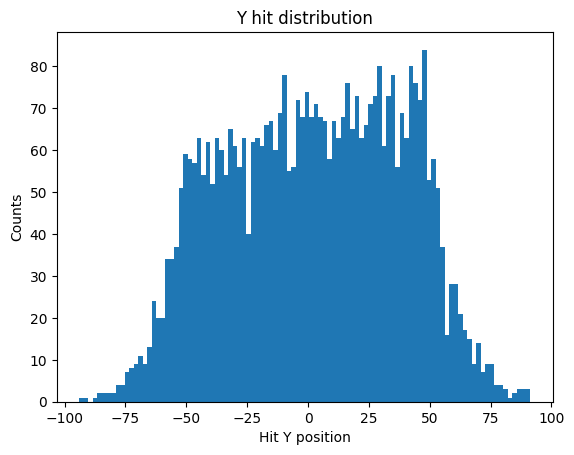

In [23]:
Y = tree["Gamma1_HitY1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Y position")
plt.ylabel("Counts")
plt.title("Y hit distribution")
plt.show()

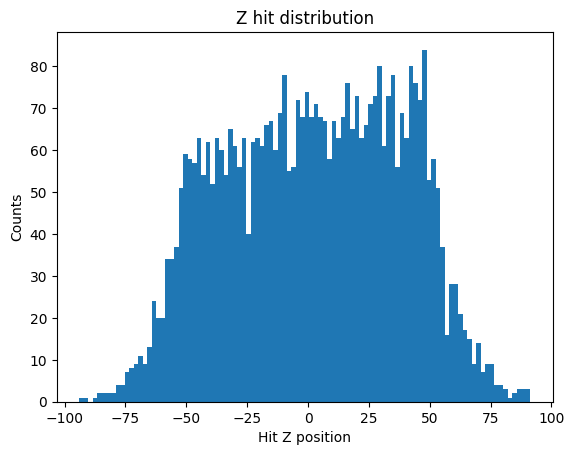

In [24]:
Z = tree["Gamma1_HitZ1"].array(library="np")

plt.hist(x, bins=100)
plt.xlabel("Hit Z position")
plt.ylabel("Counts")
plt.title("Z hit distribution")
plt.show()

energy spectrum

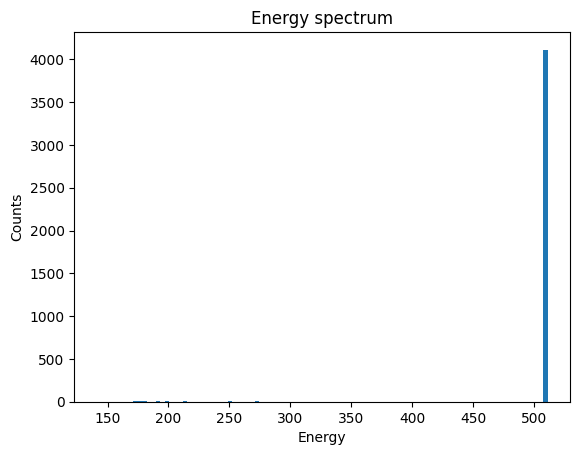

In [25]:
import uproot
import matplotlib.pyplot as plt

f = uproot.open("test.root")
tree = f[list(f.keys())[0]]

energy = tree["Gamma1_HitE1"].array(library="np")

plt.hist(energy, bins=100)
plt.xlabel("Energy")
plt.ylabel("Counts")
plt.title("Energy spectrum")
plt.show()

In [30]:
import numpy as np
f = uproot.open("test.root")
tree = f["NCS"]

g1 = tree["Gamma1_Theta"].array(library="np")
g2 = tree["Gamma2_Theta"].array(library="np")

print(np.mean(g1))
print(np.mean(g2))
print(np.allclose(g1, g2))

0.0
0.0
True


hit multiplicity

In [27]:
import awkward as ak

e1_ak = tree["Gamma1_HitE1"].array(library="ak")
hits_per_event = ak.num(e1_ak)

plt.hist(hits_per_event, bins=50)
plt.title("Hits per event")
plt.show()

AxisError: axis=1 exceeds the depth of this array (1)

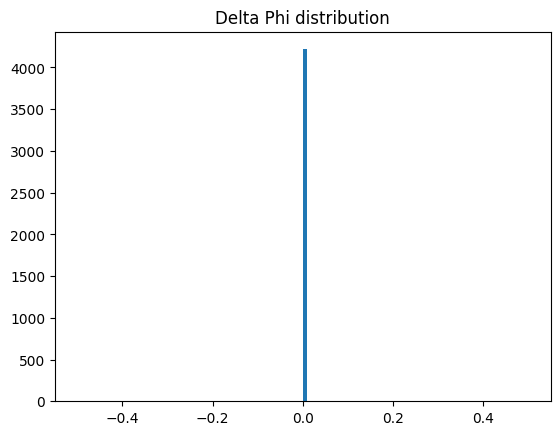

In [28]:
dphi = tree["DeltaPhi"].array(library="np")

plt.hist(dphi, bins=100)
plt.title("Delta Phi distribution")
plt.show()

In [31]:
print(g1[:20])
print(g2[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
